# Data exploration

In [38]:
# get necessary dependancies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# get data
file_path="../data/cleaned_buenos_aires_estate.csv"
data_df=pd.read_csv(file_path)
data_df

In [28]:
# get statistical summary of numeric columns
data_df.describe()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,lat,lon
count,3.807300e+04,3.807300e+04,3.807300e+04,29871.000000,36420.000000,24449.000000,32642.000000,6505.000000,23806.000000,4.452000e+03,34734.000000,34734.000000
mean,2.959661e+05,3.537121e+06,2.332824e+05,269.157578,244.493904,1718.387879,3737.943768,10.789700,3.058305,4.499551e+15,-34.521689,-58.542895
std,4.940386e+05,4.781742e+06,3.153684e+05,1686.328201,10371.179349,1497.571317,11657.891695,79.735358,1.412714,3.002249e+17,2.260135,1.602046
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.056686,1.000000,1.000000,1.000000e+00,-45.857779,-122.419415
25%,9.500000e+04,1.364616e+06,9.000000e+04,47.000000,46.000000,931.372549,1454.545455,2.000000,2.000000,8.000000e+02,-34.642425,-58.582108
50%,1.550000e+05,2.198548e+06,1.450000e+05,90.000000,76.000000,1600.000000,1964.285714,3.000000,3.000000,1.600000e+03,-34.598047,-58.498239
75%,2.950000e+05,3.942224e+06,2.600000e+05,248.000000,160.000000,2193.668000,2666.666667,6.000000,4.000000,3.100000e+03,-34.524870,-58.421971
max,1.500000e+07,2.274360e+08,1.500000e+07,192014.000000,987897.000000,54990.000000,749000.000000,2103.000000,32.000000,2.003200e+19,43.381307,3.379206


In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   price                       38073 non-null  float64
 3   currency                    38072 non-null  str    
 4   price_aprox_local_currency  38073 non-null  float64
 5   price_aprox_usd             38073 non-null  float64
 6   surface_total_in_m2         29871 non-null  float64
 7   surface_covered_in_m2       36420 non-null  float64
 8   price_usd_per_m2            24449 non-null  float64
 9   price_per_m2                32642 non-null  float64
 10  floor                       6505 non-null   float64
 11  rooms                       23806 non-null  float64
 12  expenses                    4452 non-null   float64
 13  property_url                43029 non-null

In [ ]:
# check for unique values in  operation column
data_df["operation"].unique()

<StringArray>
['sell']
Length: 1, dtype: str

In [10]:
# check for unique values in currency column
data_df["currency"].unique()

<StringArray>
['USD', nan, 'ARS']
Length: 3, dtype: str

In [12]:
# check for unique values in property type column
data_df["property_type"].unique()

<StringArray>
['house', 'apartment', 'PH', 'store']
Length: 4, dtype: str

In [14]:
# check for unique values in state column
data_df["state"].value_counts()

state
Bs.As. G.B.A. Zona Norte    15469
Capital Federal             12491
Bs.As. G.B.A. Zona Oeste    10370
Bs.As. G.B.A. Zona Sur       4699
Name: count, dtype: int64

In [15]:
data_df.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,property_url,state,lat,lon
0,sell,house,180000.0,USD,2729232.0,180000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://moreno.properati.com.ar/10rhr_venta_cas...,Bs.As. G.B.A. Zona Oeste,NaN,NaN
1,sell,house,125000.0,USD,1895300.0,125000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://moron-bs-as-g-b-a-zona-oeste.properati....,Bs.As. G.B.A. Zona Oeste,-34.662416,-58.604473
2,sell,apartment,175000.0,USD,2653420.0,175000.0,100.0,92.0,1750.0,1902.173913,NaN,4.0,2.0,http://lanus.properati.com.ar/pzqo_venta_depar...,Bs.As. G.B.A. Zona Sur,-34.703368,-58.392392
3,sell,PH,NaN,NaN,NaN,NaN,199.0,110.0,NaN,NaN,NaN,3.0,NaN,http://ramos-mejia.properati.com.ar/sat2_venta...,Bs.As. G.B.A. Zona Oeste,NaN,NaN
4,sell,apartment,90000.0,USD,1364616.0,90000.0,NaN,70.0,NaN,1285.714286,NaN,3.0,NaN,http://ituzaingo.properati.com.ar/smi9_venta_d...,Bs.As. G.B.A. Zona Oeste,NaN,NaN


/opt/anaconda3/envs/buenos-env/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


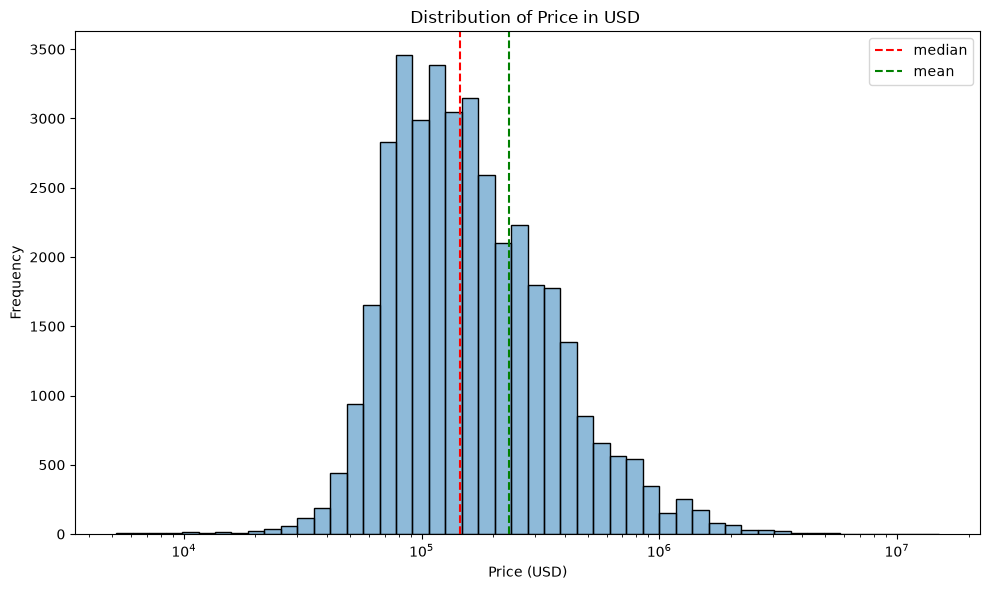

In [52]:
# visualization for price in usd
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data_df["price_aprox_usd"].dropna(),bins=50,kde=True,log_scale=True,ax=ax)
median=data_df["price_aprox_usd"].dropna().median()
mean=data_df["price_aprox_usd"].dropna().mean()
ax.axvline(median,color="red",linestyle="--",label="median")
ax.axvline(mean,color="green",linestyle="--",label="mean")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Price in USD ")
ax.legend()
plt.tight_layout()
plt.show()

price in usd is right skewed

/opt/anaconda3/envs/buenos-env/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


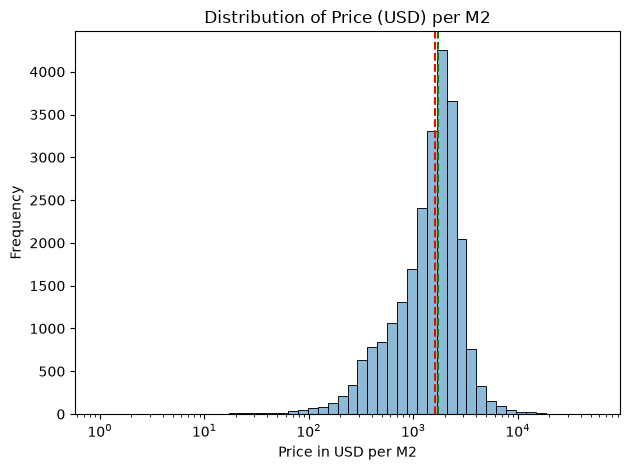

In [59]:
# visualization of price per m2 in usd
median=data_df["price_usd_per_m2"].dropna().median()
mean=data_df["price_usd_per_m2"].dropna().mean()

fig,ax=plt.subplots()
sns.histplot(data_df["price_usd_per_m2"].dropna(),bins=50,kde=True,log_scale=True)
ax.axvline(median,color="red",linestyle="--",label="median")
ax.axvline(mean,color="green",linestyle="--",label="mean")
ax.set_xlabel("Price in USD per M2")

ax.set_ylabel("Frequency")
ax.set_title("Distribution of Price (USD) per M2")
plt.tight_layout()
plt.show()

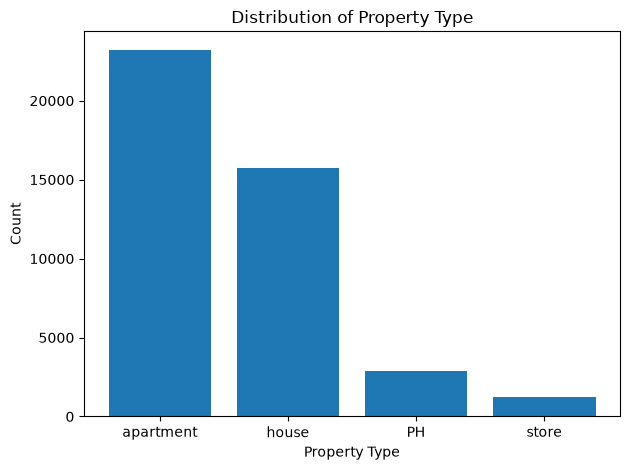

In [ ]:
# visualize how property type are distrinbbuted
property_type_count = data_df["property_type"].value_counts()
property_type_count
fig,ax=plt.subplots()
ax.bar(x=property_type_count.index,height=property_type_count.values)

ax.set_xlabel("Property Type")
ax.set_ylabel("Count")
ax.set_title("Distribution of Property Type")
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/buenos-env/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


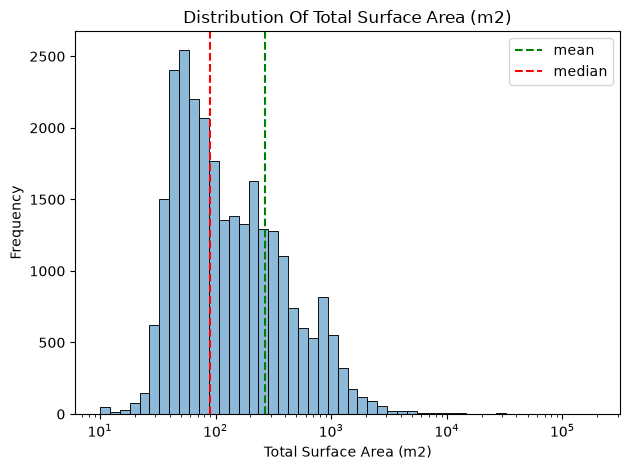

In [67]:
# visualization of of total surface area distribution
mean=data_df["surface_total_in_m2"].dropna().mean()
median=data_df["surface_total_in_m2"].dropna().median()
fig,ax=plt.subplots()
sns.histplot(data_df["surface_total_in_m2"].dropna(),bins=50,kde=True,log_scale=True)
ax.axvline(mean,color="green",label="mean",linestyle="--")
ax.axvline(median,color="red",label="median",linestyle="--")
ax.set_xlabel("Total Surface Area (m2)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution Of Total Surface Area (m2)")
ax.legend()
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/buenos-env/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


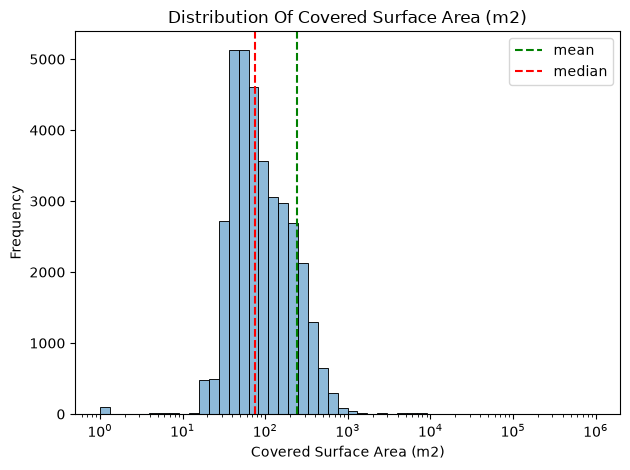

In [68]:
# visualization of of covered surface area distribution
mean=data_df["surface_covered_in_m2"].dropna().mean()
median=data_df["surface_covered_in_m2"].dropna().median()
fig,ax=plt.subplots()
sns.histplot(data_df["surface_covered_in_m2"].dropna(),bins=50,kde=True,log_scale=True)
ax.axvline(mean,color="green",label="mean",linestyle="--")
ax.axvline(median,color="red",label="median",linestyle="--")
ax.set_xlabel("Covered Surface Area (m2)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution Of Covered Surface Area (m2)")
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
# count property per state
properties_per_state=data_df["state"].value_counts()

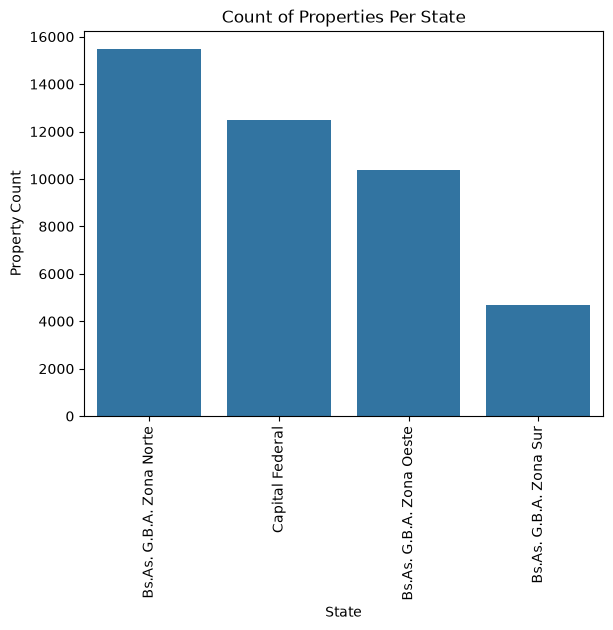

In [75]:
# distribution of price per state
fig,ax=plt.subplots()
sns.barplot(x=properties_per_state.index,y=properties_per_state.values)
ax.set_xlabel("State")
ax.set_ylabel("Property Count")
ax.set_title("Count of Properties Per State")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

##### How is price distributed across different state

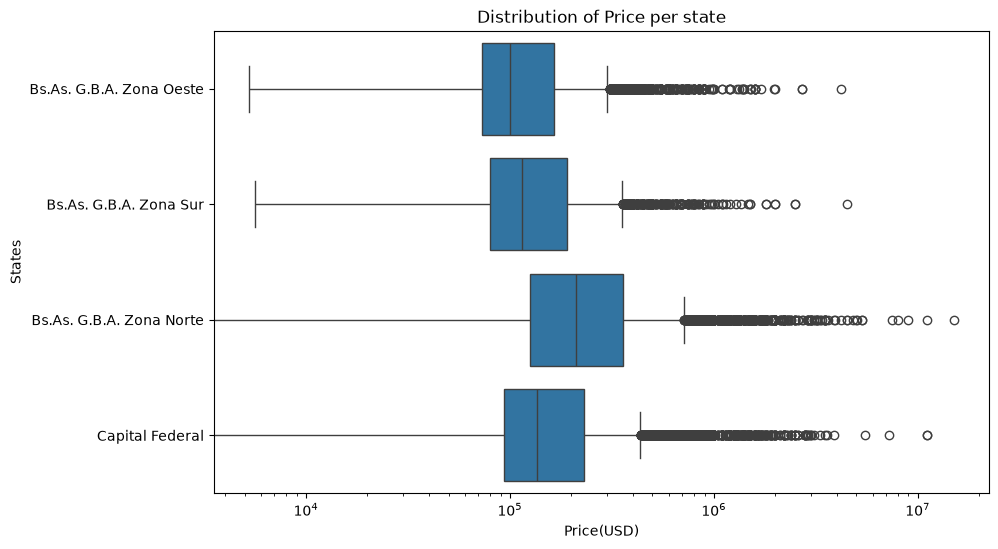

In [ ]:
# price distribution per state
fig,ax=plt.subplots(figsize=(10,6))
sns.boxplot(data=data_df,x="price_aprox_usd",y="state",ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Price(USD)")
ax.set_ylabel("States")
ax.set_title("Distribution of Price per state")
plt.show()


### Findings

1. Property prices in **Zona Oeste, Zona Sur, and Capital Federal** are right-skewed, while **Zona Norte** has a more balanced distribution.

2. The **typical property price (median)** varies across the different states.

3. All states have **high-price outliers**, indicating that some properties are considerably more expensive than the majority of properties.


In [78]:
data_df.columns

Index(['operation', 'property_type', 'price', 'currency',
       'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2',
       'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor',
       'rooms', 'expenses', 'property_url', 'state', 'lat', 'lon'],
      dtype='str')

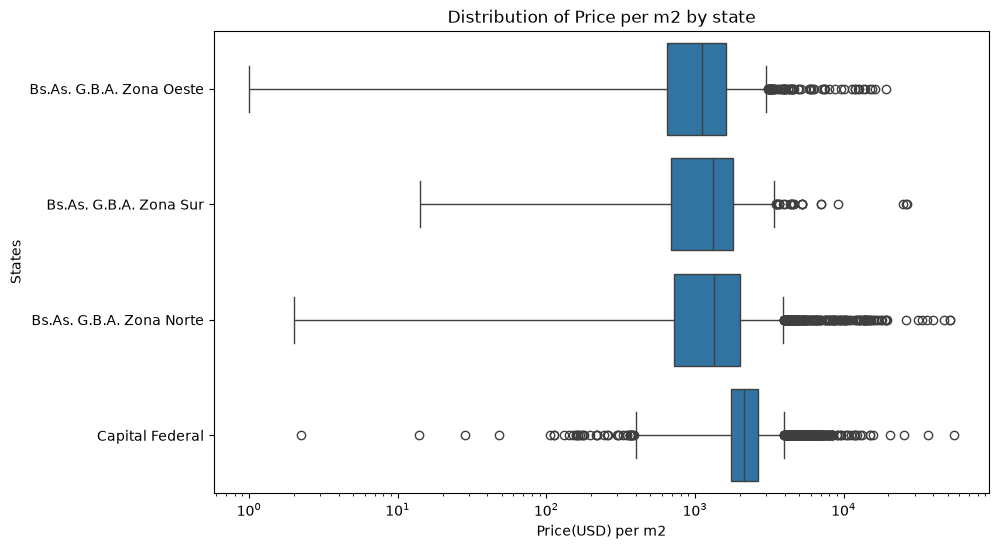

In [88]:
# price distribution per state per square metre
fig,ax=plt.subplots(figsize=(10,6))
sns.boxplot(data=data_df,x="price_usd_per_m2",y="state",ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Price(USD) per m2")
ax.set_ylabel("States")
ax.set_title("Distribution of Price per m2 by state")
plt.show()

### Findings

1. Price per square meter is **left-skewed** in Zona Oeste, Zona Sur, and Zona Norte, while Capital Federal has a more balanced distribution.

2. The **typical price per square meter (median)** varies across the states.

3. Zona Oeste, Zona Sur, and Zona Norte have **high-price outliers**, while Capital Federal has both **lower- and higher-price outliers**.


How does price compare per property type

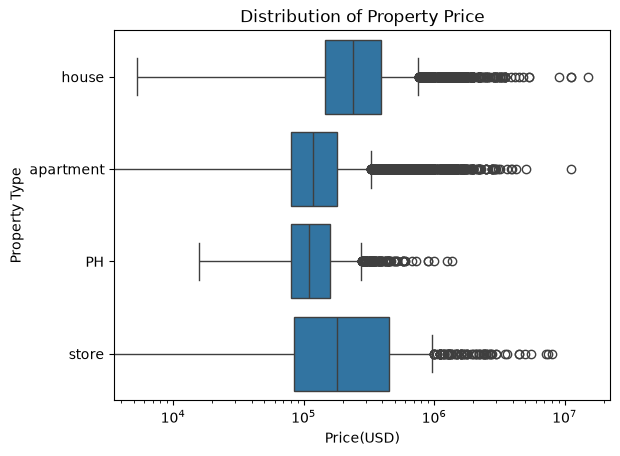

In [91]:
fig,ax=plt.subplots()
sns.boxplot(data=data_df,x="price_aprox_usd",y="property_type",ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Price(USD)")
ax.set_ylabel("Property Type")
ax.set_title("Distribution of Property Price")
plt.show()

### Findings

1. The **typical property price (median)** varies by property type.

2. Property prices show a **fairly symmetric distribution** across the property types.

3. All property types have **high-price outliers**, indicating some properties are considerably more expensive than the typical property.

4. **The spread of property prices varies across property types**, with some types showing greater variation than others.


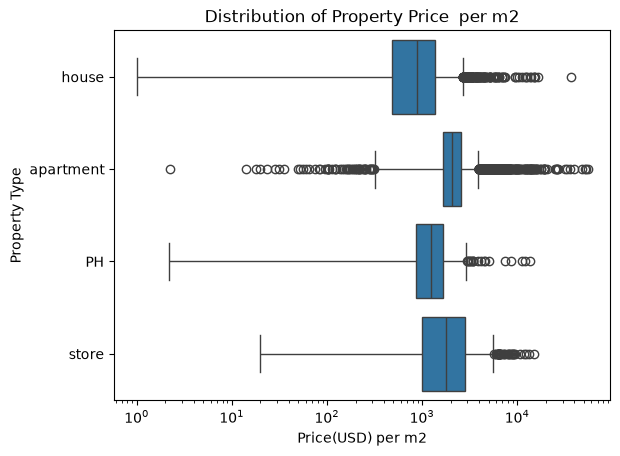

In [92]:
# price distribution per squared meter by property type
fig,ax=plt.subplots()
sns.boxplot(data=data_df,x="price_usd_per_m2",y="property_type",ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Price(USD) per m2")
ax.set_ylabel("Property Type")
ax.set_title("Distribution of Property Price  per m2")
plt.show()

### Findings

1. The **typical price per square meter (median)** varies across property types.

2. Price per square meter is **left-skewed** for houses, PHs, and stores, while apartments have a **more symmetrical distribution**.

3. All property types have **high-price outliers**, while apartments also have **low-price outliers**.


## What the relationship between area and price?

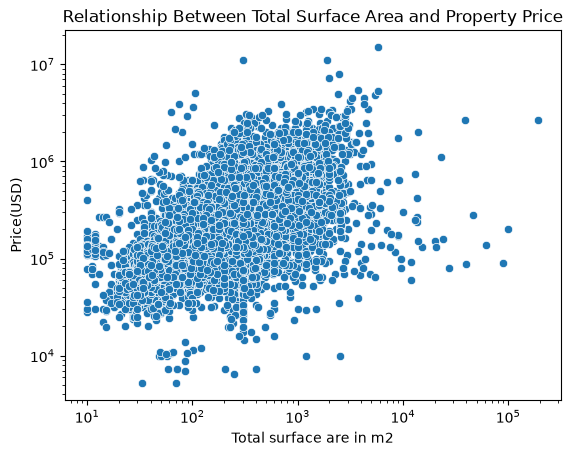

In [97]:
# compare overal price and total surface area
fig,ax=plt.subplots()
sns.scatterplot(data=data_df,x="surface_total_in_m2",y="price_aprox_usd",ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total surface are in m2")
ax.set_ylabel("Price(USD)")
ax.set_title("Relationship Between Total Surface Area and Property Price")

plt.show()

In [98]:
data_df["surface_total_in_m2"].corr(data_df["price_aprox_usd"])

np.float64(0.15020723727584093)

### finding
- positive trend
- weak positive correlation

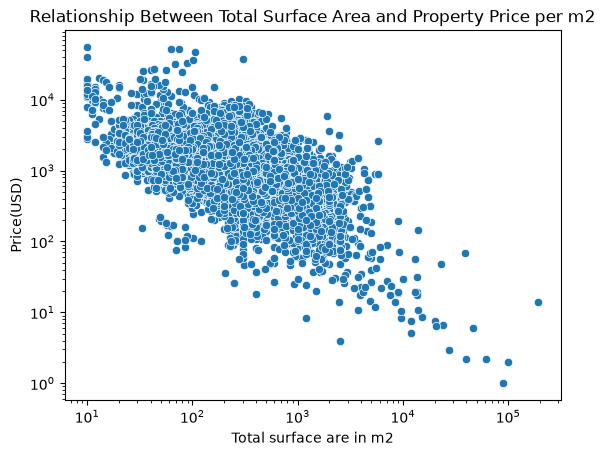

In [103]:
# compare price per m2 and total surface area

fig,ax=plt.subplots()
sns.scatterplot(data=data_df,x="surface_total_in_m2",y="price_usd_per_m2",ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total surface are in m2")
ax.set_ylabel("Price(USD)")
ax.set_title("Relationship Between Total Surface Area and Property Price per m2")

plt.show()

In [102]:
data_df["surface_total_in_m2"].corr(data_df["price_usd_per_m2"])

np.float64(-0.09119318356954773)

### finding
price per m2 decreases as total surface area increase .  negative correlation

Text(0.5, 1.0, 'Relationship Between Covered Surface Area and Property Price')

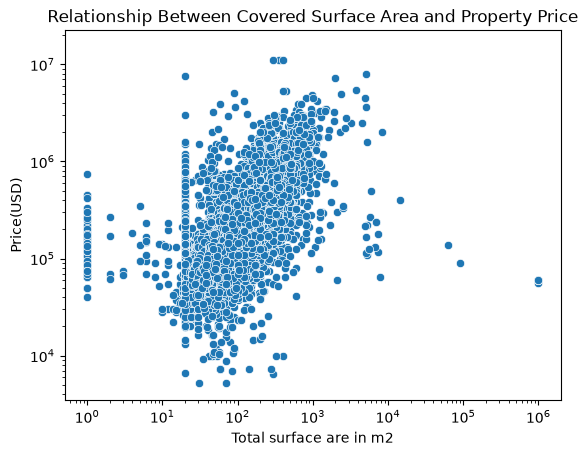

In [ ]:
# compare price  with covered surface a area

fig,ax=plt.subplots()
sns.scatterplot(data=data_df,x="surface_covered_in_m2",y="price_aprox_usd",ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total surface are in m2")
ax.set_ylabel("Price(USD)")
ax.set_title("Relationship Between Covered Surface Area and Property Price")

Text(0.5, 1.0, 'Relationship Between Covered Surface Area and Property Price per m2')

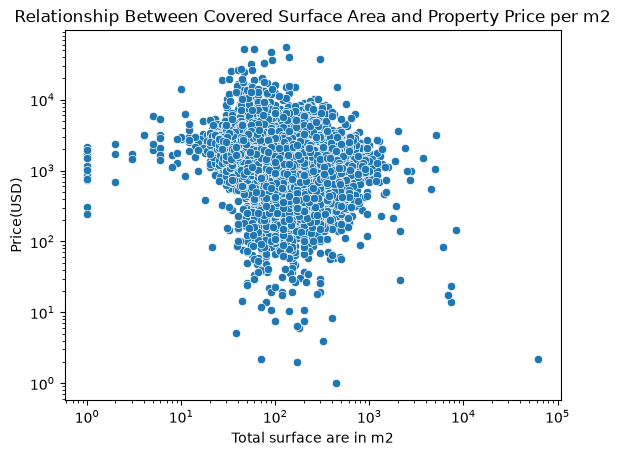

In [107]:
# compare price per m2   with covered surface a area

fig,ax=plt.subplots()
sns.scatterplot(data=data_df,x="surface_covered_in_m2",y="price_usd_per_m2",ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total surface are in m2")
ax.set_ylabel("Price(USD)")
ax.set_title("Relationship Between Covered Surface Area and Property Price per m2")

### Findings
- Overall Price increase as covered surface area increase
- No clear relationship between covered surface area and price per m2 
